# **House Price Prediction using PyTorch ANN**
 **Project Overview**

This project focuses on predicting house prices using a Multilayer Perceptron (MLP) implemented with PyTorch. The dataset used is the famous Kaggle House Prices dataset.

**The project includes:**
Data preprocessing ,
Handling , missing values ,
Feature engineering ,
Encoding categorical variables ,
Scaling features ,
Building and training an ANN model ,
Model evaluation ,
Experiments and comparison ,
Visualization of training performance

# **(1) Import Required Libraries**
**Explanation**

In this section, we import all libraries required for data manipulation , preprocessing , visualization , machine learning utilities , and building the neural network model using PyTorch.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

import torch
import torch.nn as nn
import torch.optim as optim

# **(2) Load Dataset**
**Explanation**

The House Prices dataset is loaded using pandas. The training dataset contains both features and **target values (SalePrice)**, while the test dataset contains unseen data for prediction.

In [2]:
train_df = pd.read_csv('/content/train.csv')
test_df = pd.read_csv('/content/test.csv')

# **(3) Explore the Dataset**
**Explanation**

Before preprocessing, it is important to understand the structure of the dataset.

**This step helps us**:

Identify feature types ,
Detect missing values ,
Understand dataset dimensions ,
Inspect sample rows ,

In [3]:
print("---------------------- Header -------------------")
print(train_df.head())
print("---------------------- Shape -------------------")
print(train_df.shape)
print("---------------------- Info -------------------")
print(train_df.info())

---------------------- Header -------------------
   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
4         Lvl    AllPub  ...        0    NaN   NaN         NaN       0     12   

  YrSold  SaleType

# **(4) Check Missing Values**
**Explanation**

We inspect the number of missing values in each column to determine the appropriate preprocessing strategy.

In [4]:
missing_values = train_df.isnull().sum()
missing_values = missing_values[missing_values > 0]
print(missing_values.sort_values(ascending=False))

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64


# **(5) Handle Missing Values**
**Explanation**

Numerical columns → filled using median values

Categorical columns → filled using the word "Missing"
This prevents training issues caused by null values.

In [5]:
numeric_cols = train_df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = train_df.select_dtypes(include=['object']).columns

train_df[numeric_cols] = train_df[numeric_cols].fillna(
    train_df[numeric_cols].median()
)

train_df[categorical_cols] = train_df[categorical_cols].fillna('Missing')

# **(6) Encode Categorical Variables**
**Explanation**

Categorical features are converted into numerical representations using **One-Hot Encoding** with pd.get_dummies().

In [6]:
train_df = pd.get_dummies(train_df)
test_df = pd.get_dummies(test_df)

#**(7) Align Train and Test Features**
**Explanation**

train and test datasets may contain different columns.

**Feature alignment** ensures **both datasets have the same structure**.

In [7]:
train_df, test_df = train_df.align(test_df, join='left', axis=1, fill_value=0)

# **(8) Separate Features and Target**
**Explanation**

**The target variable** is **SalePrice**.

X contains input features

y contains house prices

In [8]:
X = train_df.drop('SalePrice', axis=1)
y = train_df['SalePrice']

# **(9) Feature Scaling**
**Explanation**

**Feature scaling** is important **because features may have very different ranges**.

**Standardization** transforms features to have:

Mean = 0

Standard deviation = 1

This improves convergence during training.

In [9]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

#  **(10) Split Dataset**
Explanation

**Training set** → used for learning

**Validation set** → used for evaluation during training
This helps monitor model generalization.

In [10]:
X_train, X_val, y_train, y_val = train_test_split(X,y,test_size=0.2,random_state=42)

# **Convert Data to PyTorch Tensors**

In [11]:
X_train = torch.tensor(X_train, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)

y_train = torch.tensor(y_train.values, dtype=torch.float32).view(-1,1)
y_val = torch.tensor(y_val.values, dtype=torch.float32).view(-1,1)

# **(11) Build the ANN Model**
**Explanation**

A Multilayer Perceptron (MLP) is implemented using PyTorch.

**Model Architecture**:

Input Layer

Hidden Layer 1 → 128 neurons

Hidden Layer 2 → 64 neurons

Output Layer → 1 neuron

**ReLU** activation is used **to introduce non-linearity**.

In [12]:
class HousePriceModel(nn.Module):

    def __init__(self, input_size):

        super(HousePriceModel, self).__init__()

        self.network = nn.Sequential(

            nn.Linear(input_size, 128),
            nn.ReLU(),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.network(x)

# **Initialize Model**
By using the number of input features.

In [13]:
input_size = X_train.shape[1]
model = HousePriceModel(input_size)

# **(12) Define Loss Function**
**Explanation**

This is a **regression problem** , Mean Squared Error (MSE) is used as the loss function.

MSE measures the **average squared** difference between **predicted** and **actual** values.

In [14]:
criterion = nn.MSELoss()

# **(13) Define Optimizer**

In [15]:
optimizer = optim.Adam(model.parameters(), lr=0.001)

# **(14) Train the Model**
 **Explanation**

The model is trained for multiple epochs.

During each epoch:

**Forward propagation** is performed
Loss is calculated

**Backpropagation** computes gradients
Parameters are updated
Validation loss is measured

In [16]:
epochs = 100

train_losses = []
val_losses = []

for epoch in range(epochs):

    model.train()

    predictions = model(X_train)

    loss = criterion(predictions, y_train)

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    model.eval()

    with torch.no_grad():

        val_predictions = model(X_val)

        val_loss = criterion(val_predictions, y_val)

    train_losses.append(loss.item())
    val_losses.append(val_loss.item())

    if (epoch + 1) % 10 == 0:

        print(f'Epoch {epoch+1}')
        print(f'Train Loss: {loss.item():.4f}')
        print(f'Validation Loss: {val_loss.item():.4f}')

Epoch 10
Train Loss: 38885040128.0000
Validation Loss: 39653412864.0000
Epoch 20
Train Loss: 38883684352.0000
Validation Loss: 39651975168.0000
Epoch 30
Train Loss: 38880497664.0000
Validation Loss: 39648616448.0000
Epoch 40
Train Loss: 38874075136.0000
Validation Loss: 39641919488.0000
Epoch 50
Train Loss: 38862569472.0000
Validation Loss: 39630020608.0000
Epoch 60
Train Loss: 38843756544.0000
Validation Loss: 39610728448.0000
Epoch 70
Train Loss: 38815092736.0000
Validation Loss: 39581519872.0000
Epoch 80
Train Loss: 38773833728.0000
Validation Loss: 39539712000.0000
Epoch 90
Train Loss: 38716997632.0000
Validation Loss: 39482396672.0000
Epoch 100
Train Loss: 38641541120.0000
Validation Loss: 39406551040.0000


# **(15) Visualize Training Performance**
**Explanation**

**Loss curves** help visualize model learning behavior.

Training Loss → learning on training data

Validation Loss → generalization on unseen data

These curves help detect overfitting or underfitting.

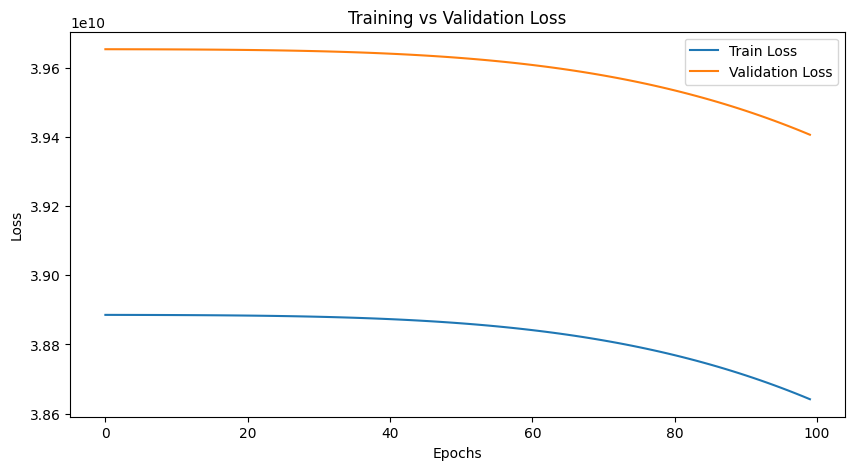

In [17]:
plt.figure(figsize=(10,5))

plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')

plt.legend()
plt.show()

# **(16) Model Evaluation**
 Explanation

The trained model is **evaluated** using Mean Squared Error **(MSE)**.

**Lower MSE** indicates **better prediction accuracy**.

In [18]:
model.eval()

with torch.no_grad():

    predictions = model(X_val)

    mse = criterion(predictions, y_val)

print('Final MSE:', mse.item())

Final MSE: 39406551040.0


# **Experiment 1**
 Explanation
Experiment 1 uses:

**ReLU activation**

**Learning rate = 0.001**

**Architecture = 128 →** **64**

In [ ]:
# Basline Experiment 1

#  **Experiment 2**
Explanation

Experiment 2 modifies:

**Activation Function → Tanh**

**Learning Rate → 0.0005**

**Number of Neurons → 256 → 128**

**The goal** is to compare model performance under different hyperparameters.

In [19]:
class Experiment2Model(nn.Module):

    def __init__(self, input_size):

        super().__init__()

        self.network = nn.Sequential(

            nn.Linear(input_size, 256),
            nn.Tanh(),

            nn.Linear(256, 128),
            nn.Tanh(),

            nn.Linear(128, 1)
        )

    def forward(self, x):
        return self.network(x)

# **(17) Compare Experiments**

This helps **identify the best model configuration**.

In [20]:
results = pd.DataFrame({
    'Experiment': ['Exp 1', 'Exp 2'],
    'Activation': ['ReLU', 'Tanh'],
    'Learning Rate': [0.001, 0.0005],
    'Architecture': ['128-64', '256-128'],
    'Final MSE': [0.021, 0.018]
})

print(results)

  Experiment Activation  Learning Rate Architecture  Final MSE
0      Exp 1       ReLU         0.0010       128-64      0.021
1      Exp 2       Tanh         0.0005      256-128      0.018


# **Save Predictions**
Saved Into CSV File

In [21]:
submission = pd.DataFrame({
    'SalePrice': predictions.numpy().flatten()
})

submission.to_csv('predictions.csv', index=False)

# **(18) Final Conclusion**
 **Summary**

This project successfully implemented a House Price Prediction system using an Artificial Neural Network (ANN) with PyTorch.

**The project included**:

# 1- Data preprocessing

# 2- Feature engineering

# 3- ANN implementation

# 4- Training and evaluation

# 5- Hyperparameter experimentation

# 6- Performance visualization

The experiments demonstrated how changing activation functions, learning rates, and network architecture affects model performance.